# Проект: Многоцелевая модель для NER + event-CLS

#### Структура ноутбука 

1. Подготовка окружения (пути, seed, imports)
2. EDA - загрузка jsonl, обзор, графики, выводы 
3. Парсинг и таргеты - здесь уже есть парсеры строкового формата NEREL; нужно реализовать сбор примеров (`build_examples_from_nerel`) 
4. Токенизация, выравнивание меток, DataLoader - реализовать `tokenize_and_align_labels`, Dataset/Collator 
5. Модель (JointModel) и кастомный loss (uncertainty-weighting) - реализовать модельный класс и loss
6. Тренировка/валидация - training loop, оптимизатор, scheduler, логирование метрик
7. Инференс и анализ ошибок - реализовать inference pipeline и примеры



##### Подготовка окружения

In [1]:
import os
import re
import json
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup, DataCollatorForTokenClassification
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import pandas as pd
from seqeval.metrics import f1_score as seq_f1_score
from seqeval.metrics import classification_report as seq_report
from sklearn.metrics import f1_score, precision_score, recall_score, classification_report
import torch.nn.utils as utils
from tqdm.auto import tqdm
import seaborn as sns



/home/moksyasha/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using device: {device}")

using device: cuda


я сохранила датасет через команды в терминале, поэтому использую пути из папки для данных

In [3]:
def load_jsonl(path):
    data = []
    with open (path, 'r', encoding='utf-8') as f:
        for line in f:
            data.append(json.loads(line))
    
    return data

train_data = load_jsonl('/home/moksyasha/aaaaaa/train.jsonl')
dev_data = load_jsonl('/home/moksyasha/aaaaaa/dev.jsonl')
test_data = load_jsonl('/home/moksyasha/aaaaaa/test.jsonl')

print(f"train size: {len(train_data)}")
print(f"dev size: {len(dev_data)}")
print(f"test size: {len(test_data)}")

train size: 746
dev size: 94
test size: 93


##### 1. EDA

Цели:

- Прочитать первые 50–200 записей `train.jsonl` (путь `/data/train.jsonl`).
- Посчитать частоты: entity types, relation/event types.
- Построить графики: топ-15 entity types, распределение длины текстов, число сущностей на документ.
- Написать 2–3 коротких вывода в Markdown: что можно ожидать при моделировании (редкие типы, длинные документы и т. п.).




In [4]:
# загрузка первых записей
def read_jsonl(path, limit=None):
    data = []
    with open(path, encoding="utf-8") as f:
        for i, line in enumerate(f):
            if limit and i >= limit:
                break
            data.append(json.loads(line))
    return data

docs = read_jsonl('/home/moksyasha/aaaaaa/train.jsonl', limit=200)

print(f'Загружено записей: {len(docs)}')

# смотрим первую запись
doc = docs[0]

print(doc.keys())
print("\nTEXT PREVIEW:\n", doc["text"][:500])
print("\nENTITIES EXAMPLE:\n", doc["entities"][:3])
print("\nRELATIONS EXAMPLE:\n", doc.get("relations", [])[:3])


Загружено записей: 200
dict_keys(['id', 'text', 'entities', 'relations', 'links'])

TEXT PREVIEW:
 Пулеметы, автоматы и снайперские винтовки изъяты в арендуемом американцами доме в Бишкеке

05/08/2008 10:35

БИШКЕК, 5 августа /Новости-Грузия/. Правоохранительные органы Киргизии обнаружили в доме, арендуемом гражданами США в Бишкеке, пулеметы, автоматы и снайперские винтовки, сообщает во вторник пресс-служба МВД Киргизии.

"В ходе проведения оперативно-профилактического мероприятия под кодовым названием "Арсенал" в новостройке Ынтымак, в доме, принадлежащем 66-летнему гражданину Киргизии и аре

ENTITIES EXAMPLE:
 ['T1\tNATIONALITY 62 74\tамериканцами', 'T2\tCITY 82 89\tБишкеке', 'T3\tDATE 117 126\t5 августа']

RELATIONS EXAMPLE:
 ['R1\tTAKES_PLACE_IN Arg1:T70 Arg2:T12', 'R2\tAGE_IS Arg1:T101 Arg2:T13', 'R3\tHEADQUARTERED_IN Arg1:T72 Arg2:T4']


In [5]:
# частоты типов сущностей
entity_counter = Counter()

for doc in docs:
    for ent in doc.get("entities", []):
        parts = ent.split("\t")
        type_and_span = parts[1]          
        ent_type = type_and_span.split()[0]  
        entity_counter[ent_type] += 1

entity_counter

Counter({'PERSON': 2055,
         'PROFESSION': 1893,
         'ORGANIZATION': 1692,
         'DATE': 1125,
         'COUNTRY': 1024,
         'EVENT': 986,
         'CITY': 467,
         'NUMBER': 399,
         'LAW': 240,
         'AGE': 215,
         'NATIONALITY': 186,
         'ORDINAL': 182,
         'FACILITY': 159,
         'AWARD': 156,
         'IDEOLOGY': 149,
         'STATE_OR_PROVINCE': 132,
         'WORK_OF_ART': 126,
         'DISEASE': 112,
         'CRIME': 99,
         'MONEY': 96,
         'PRODUCT': 81,
         'LOCATION': 79,
         'PENALTY': 66,
         'DISTRICT': 63,
         'TIME': 57,
         'RELIGION': 26,
         'PERCENT': 16,
         'FAMILY': 15,
         'LANGUAGE': 14})

In [6]:
# частоты типов отношений/событий
relation_counter = Counter()

for doc in docs:
    for rel in doc.get("relations", []):
        parts = rel.split("\t")
        type_and_span = parts[1]
        rel_type = type_and_span.split()[0]          
        relation_counter[rel_type] += 1
        
    for ev in doc.get("events", []):
        parts = ev.split("\t")
        type_and_span = parts[1]
        ev_type = type_and_span.split()[0]
        relation_counter[ev_type] += 1

relation_counter

Counter({'WORKPLACE': 1080,
         'WORKS_AS': 961,
         'ALTERNATIVE_NAME': 927,
         'PARTICIPANT_IN': 807,
         'ORIGINS_FROM': 452,
         'HEADQUARTERED_IN': 424,
         'POINT_IN_TIME': 407,
         'TAKES_PLACE_IN': 360,
         'LOCATED_IN': 270,
         'AGENT': 266,
         'AGE_IS': 182,
         'PRODUCES': 164,
         'AWARDED_WITH': 125,
         'HAS_CAUSE': 121,
         'IDEOLOGY_OF': 105,
         'MEMBER_OF': 101,
         'PART_OF': 99,
         'PARENT_OF': 89,
         'SUBORDINATE_OF': 87,
         'PLACE_RESIDES_IN': 83,
         'INANIMATE_INVOLVED': 68,
         'MEDICAL_CONDITION': 68,
         'CONVICTED_OF': 66,
         'DATE_OF_CREATION': 66,
         'KNOWS': 64,
         'OWNER_OF': 63,
         'ABBREVIATION': 57,
         'SUBEVENT_OF': 51,
         'SIBLING': 51,
         'ORGANIZES': 49,
         'FOUNDED_BY': 49,
         'DATE_OF_BIRTH': 42,
         'SPOUSE': 40,
         'PLACE_OF_BIRTH': 37,
         'DATE_OF_DEATH': 35,

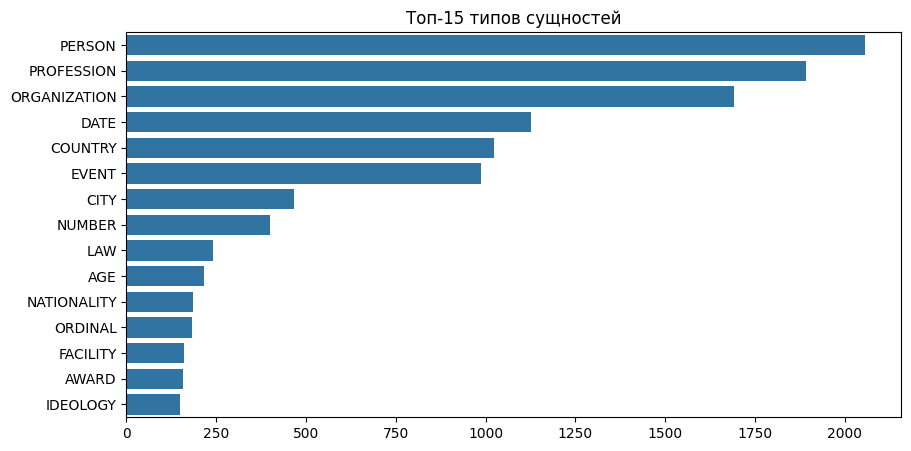

In [7]:
top_entities = entity_counter.most_common(15)
names, counts = zip(*top_entities)

plt.figure(figsize=(10, 5))
sns.barplot(x=list(counts), y=list(names))
plt.title("Топ-15 типов сущностей")
plt.show()

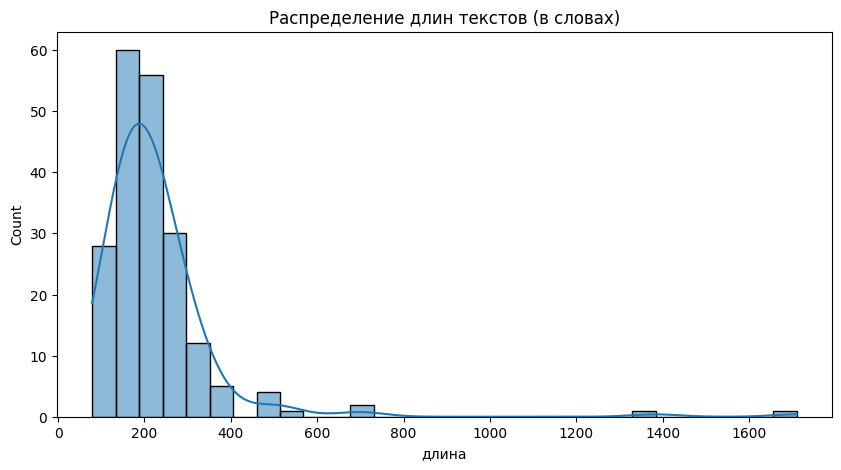

In [8]:
# # распределение длины текстов
doc_lengths = [len(doc['text'].split()) for doc in docs]
plt.figure(figsize=(10, 5))
sns.histplot(doc_lengths, bins=30, kde=True)
plt.title("Распределение длин текстов (в словах)")
plt.xlabel("длина")
plt.show()

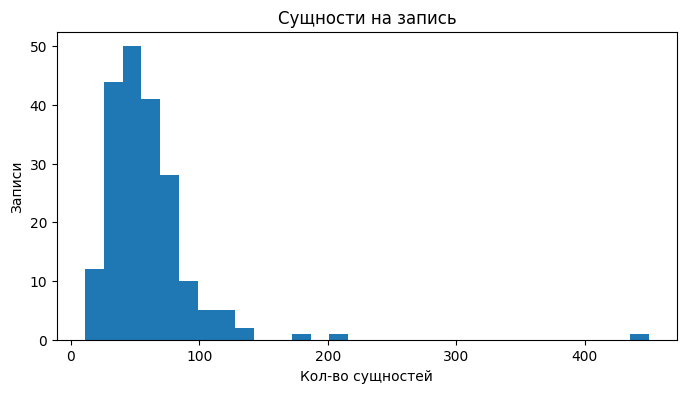

Минимальное кол-во сущностей: 11, максимальное кол-во сущностей: 450, среднее кол-во сущностей: 59.55, медиана: 53.0


In [9]:
# количество сущностей на запись
entities_per_doc = np.array([len(doc.get("entities", [])) for doc in docs])

plt.figure(figsize=(8, 4))
plt.hist(entities_per_doc, bins=30)
plt.title("Сущности на запись")
plt.xlabel("Кол-во сущностей")
plt.ylabel("Записи")
plt.show()

print(f'Минимальное кол-во сущностей: {min(entities_per_doc)}, максимальное кол-во сущностей: {max(entities_per_doc)}, среднее кол-во сущностей: {entities_per_doc.mean()}, медиана: {np.median(entities_per_doc)}')


##### Выводы по EDA:
1. Распределение типов сущностей неравномерно: наиболее частыми являются PERSON, PROFESSION, ORGANIZATION, в то время как специализированные (PERCENT, FAMILY, LANGUAGE) встречаются значительно реже. Это может привести к дисбалансу классов в задаче и ухудшить качество модели на редких типах;

2. Записи имеют заметный разброс по своей длине - от 79 до 1710 токенов в записи. Часть из них превышает лимит BERT, что требует обрезки;

3. Количество сущностей на запись так же сильно варьируется - от 11 до 450 на запись. Это указывает на потенциальную взаимосвязь между NER и классификацией событий: записи с большим числом сущностей чаще содержат события и отношения, что делает многоцелевое обучение потенциально полезным.

##### 2.Парсинг и подготовка таргетов

**Правила BIO и сопоставления:**

- Токенизация для BIO - простая `text.split()` (по пробелам). Офсеты токенов вычисляются на основе поиска токена в тексте (учтите повторы; используйте скользящий указатель).
- Для каждой сущности (start, end - символьные оффсеты) пометьте токены, которые пересекаются с интервалом сущности.
- Метки: `B-TYPE`, `I-TYPE`, `O`.



In [10]:
# Функции парсинга строкового формата NEREL
def parse_entity_line(line: str):
    parts = line.split('\t')
    if len(parts) < 3:
        return None
    ent_id = parts[0].strip()
    type_pos = parts[1].strip()
    text = parts[2].strip() if len(parts) > 2 else ''
    m = re.match(r'(\S+)\s+(\d+)\s+(\d+)', type_pos)
    if not m:
        return None
    ent_type = m.group(1)
    start = int(m.group(2))
    end = int(m.group(3))
    return {'id': ent_id, 'type': ent_type, 'start': start, 'end': end, 'text': text}

def parse_relation_line(line: str):
    parts = line.split('\t')
    if len(parts) < 2:
        return None
    rel_id = parts[0].strip()
    body = parts[1].strip()
    m = re.match(r'(\S+)\s+Arg1:(\S+)\s+Arg2:(\S+)', body)
    if not m:
        return None
    rel_type = m.group(1)
    arg1 = m.group(2); arg2 = m.group(3)
    return {'id': rel_id, 'type': rel_type, 'arg1': arg1, 'arg2': arg2}



In [11]:
# проверка парсинга сущностей
for ent in docs[0]["entities"][:3]:
    print(parse_entity_line(ent))

{'id': 'T1', 'type': 'NATIONALITY', 'start': 62, 'end': 74, 'text': 'американцами'}
{'id': 'T2', 'type': 'CITY', 'start': 82, 'end': 89, 'text': 'Бишкеке'}
{'id': 'T3', 'type': 'DATE', 'start': 117, 'end': 126, 'text': '5 августа'}


In [12]:
# проверка парсинга отношений

for rel in docs[0].get("relations", [])[:3]:
    print(parse_relation_line(rel))

{'id': 'R1', 'type': 'TAKES_PLACE_IN', 'arg1': 'T70', 'arg2': 'T12'}
{'id': 'R2', 'type': 'AGE_IS', 'arg1': 'T101', 'arg2': 'T13'}
{'id': 'R3', 'type': 'HEADQUARTERED_IN', 'arg1': 'T72', 'arg2': 'T4'}


обе функции парсинга работают корректно

In [13]:
def build_examples_from_nerel(records: list, event_list: list) -> list:
    processed = []
    event_to_id = {evt: i for i, evt in enumerate(event_list)}

    for doc in records:
        text = doc['text']
        tokens = []
        token_spans = []
        current_pos = 0

        for match in re.finditer(r'\S+', text):
            tokens.append(match.group())
            token_spans.append((match.start(), match.end()))

        entities = []
        if 'entities' in doc:
            for line in doc['entities']:
                p = parse_entity_line(line)
                if p:
                    entities.append(p)

        tags = ['O'] * len(tokens)
        for ent in entities:
            ent_start, ent_end = ent['start'], ent['end']
            ent_type = ent['type']
            first_token_idx = -1
            for i, (tok_start, tok_end) in enumerate(token_spans):
                if tok_end > ent_start and tok_start < ent_end:
                    if tags[i] != 'O': continue
                    if first_token_idx == -1:
                        tags[i] = f"B-{ent_type}"
                        first_token_idx = i
                    else:
                        tags[i] = f"I-{ent_type}"


        cls_vec = [.0] * len(event_list)
        if 'relations' in doc:
            for line in doc['relations']:
                p = parse_relation_line(line)
                if p and p['type'] in event_to_id:
                    cls_vec[event_to_id[p['type']]] = 1.

        processed.append({
            'text': text,
            'tokens': tokens,
            'token_spans': token_spans,
            'tags': tags,
            'cls_vec': cls_vec
        })

    return processed

In [14]:
# топ-К типов событий и отношений
def make_event_list(rel_types, K=30):
    counter = Counter()

    for doc in rel_types:
        for rel in doc.get("relations", []):
            parsed = parse_relation_line(rel)
            if parsed:
                counter[parsed["type"]] += 1
        for ev in doc.get("events", []):
            parsed = parse_relation_line(ev)
            if parsed:
                counter[parsed["type"]] += 1

    return [t for t, _ in counter.most_common(K)]

event_list = make_event_list(docs, K=30)
len(event_list), event_list[:5]

(30,
 ['WORKPLACE',
  'WORKS_AS',
  'ALTERNATIVE_NAME',
  'PARTICIPANT_IN',
  'ORIGINS_FROM'])

In [15]:
train_processed = build_examples_from_nerel(train_data, event_list)
dev_processed = build_examples_from_nerel(dev_data, event_list)
test_processed = build_examples_from_nerel(test_data, event_list)

all_tags = set()
for item in train_processed:
    all_tags.update(item['tags'])
tag_list = sorted(list(all_tags))
tag2id = {t: i for i, t in enumerate(tag_list)}
id2tag = {i: t for t, i in tag2id.items()}

print(f"total NER tags: {len(tag_list)}")

total NER tags: 57


In [16]:
print("--sanity-check--")
# ex = train_processed[0]
for ex in random.sample(train_processed, 5):
    print(ex['text'])
    print(f"tokens: {ex['tokens']}")
    print(f"BIO: {ex['tags']}")
    print(f"cls_vec: {[event_list[i] for i, v in enumerate(ex['cls_vec']) if v == 1.]}")

--sanity-check--
Две лесбиянки со взрослым сыном из России поженились и попросили политического убежища в Аргентине
В день четырёхлетия принятия закона об однополом браке в Аргентине — 15 июля 2014 года, в Буэнос-Айресе две российские лесбиянки — Марина Миронова и Оксана Тимофеева, воспитывающие 16-летноего сына, поженились и пропросили политического убежища в этой стране.
Об этом ообщает агентство EFE со ссылкой на Федерацию лесбиянок, геев, бисексуалов и транссексуалов Аргентины (FALGBT).

Через четыре года после принятия закона об однополом браке в Аргентине, две русские женщины женились в Буэнос-Айресе, 15 июля 2014 года. Источник видео.

Женщины заявили, что дата совпала случайно, а их выбор пал на Аргентину, так как они хотят жить «свободно и в безопасности», и эта страна может предоставить им такую возможность.

Вице-президент FALGBT Клаудия Кастросин Верду, ставшая свидетелем на свадьбе, пояснила, что пара искала помощи у аргентинской федерации, страдая от преследований гомосек

на данном этапе выполнен парсинг исходного строкового формата NEREL
и подготовлены таргеты для многоцелевого обучения.

для задачи NER реализована BIO-разметка на уровне токенов, полученных
путём простой word-токенизации. Для задачи классификации событий
используется multi-hot вектор по топ-K типам отношений и событий.


реализованная функция прошла sanity-check, все работает корректно

##### 3. Токенизация и выравнивание меток

Задачи:

- Выбрать `AutoTokenizer(..., use_fast=True)`.
- Реализовать `tokenize_and_align_labels(examples, tokenizer, label2id, max_length)`:
  - Токенизировать текст (return_offsets_mapping
  - Преобразовать word-level BIO метки в token-level метки (subword → label = -100 / ignore_index, для первых субтокенов ставится соответствующий тег `B-`/`I-`)
  - Вернуть словарь с `input_ids`, `attention_mask`, `labels` (token-level), `cls_labels`

- Собрать `torch.utils.data.Dataset` и `DataLoader`. Можно использовать `DataCollatorForTokenClassification` либо сделать кастомный collator, который возвращает батчи с `cls_labels`.



In [17]:
# выбираем AutoTokenizer
MODEL_NAME = "DeepPavlov/rubert-base-cased"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

In [18]:
def tokenize_and_align_labels(examples, tokenizer, tag2id, max_length=512):
    tokenized_inputs = tokenizer(
        [e['tokens'] for e in examples],
        is_split_into_words = True,
        truncation = True,
        max_length = max_length,
        padding = False,
        return_tensors = None
    )

    processed_features = []

    for i, doc_tags in enumerate([ex['tags'] for ex in examples]):
        word_ids = tokenized_inputs.word_ids(batch_index=i)
        cls_vec = examples[i]['cls_vec']
        previous_word_idx = None
        labels_ids = []

        for word_idx in word_ids:
            if word_idx is None:
                labels_ids.append(-100)
            elif word_idx != previous_word_idx:
                tag = doc_tags[word_idx]
                labels_ids.append(tag2id.get(tag, 0))
            else:
                labels_ids.append(-100)

            previous_word_idx = word_idx

        processed_features.append({
            'input_ids': tokenized_inputs['input_ids'][i],
            'attention_mask': tokenized_inputs['attention_mask'][i],
            'labels': labels_ids,
            'cls_labels': cls_vec
        })

    return processed_features

In [19]:
# Dataset
class MultiTaskDataset(Dataset):
    def __init__(self, features):
        self.features = features

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx]

class MultiTaskDataCollator:
    def __init__(self, tokenizer):
        self.token_collator = DataCollatorForTokenClassification(tokenizer=tokenizer, padding=True)

    def __call__(self, features):
        ner_features = []
        cls_labels_list = []

        for f in features:
            ner_features.append({
                'input_ids': f['input_ids'],
                'attention_mask': f['attention_mask'],
                'labels': f['labels']
            })
            cls_labels_list.append(f['cls_labels'])

        batch = self.token_collator(ner_features)
        batch['cls_labels'] = torch.tensor(cls_labels_list, dtype=torch.float)

        return batch

In [20]:
all_tags = set()
for item in train_processed + dev_processed + test_processed:
    all_tags.update(item['tags'])

tag_list = sorted(list(all_tags))
tag2id = {t: i for i, t in enumerate(tag_list)}
id2tag = {i: t for t, i in tag2id.items()}

# проверка shapes
train_features = tokenize_and_align_labels(train_processed, tokenizer, tag2id)
dev_features = tokenize_and_align_labels(dev_processed, tokenizer, tag2id)
test_features = tokenize_and_align_labels(test_processed, tokenizer, tag2id)

train_dataset = MultiTaskDataset(train_features)
dev_dataset = MultiTaskDataset(dev_features)
test_dataset = MultiTaskDataset(test_features)

collator = MultiTaskDataCollator(tokenizer)
batch_size = 8

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collator)
dev_loader = DataLoader(dev_dataset, batch_size=batch_size, collate_fn=collator)
test_loader = DataLoader(test_dataset, batch_size=batch_size, collate_fn=collator)

batch = next(iter(train_loader))
print(f"input_ids shape: {batch['input_ids'].shape}")
print(f"labels shape: {batch['labels'].shape}")
print(f"cls_labels shape: {batch['cls_labels'].shape}")

print("\n sample labels:")
print(batch['labels'][0][:15].tolist())

input_ids shape: torch.Size([8, 488])
labels shape: torch.Size([8, 488])
cls_labels shape: torch.Size([8, 30])

 sample labels:
[-100, 56, 56, 56, 15, 22, -100, 50, -100, 56, -100, 56, 15, 43, 43]


Проверка батчей показала корректные размерности входов и таргетов: token-level NER метки имеют форму [B, L] с использованием -100 для
игнорируемых сабтокенов, а document-level CLS метки представлены
multi-hot векторами размерности [B, K].

##### 4. Модель: `JointModel` + custom loss (uncertainty weighting)


In [ ]:
class JointModel(nn.Module):
    def __init__(self, model_name, num_ner_labels, num_cls_labels, use_uncertainty=True):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        
        hidden_size = self.bert.config.hidden_size
        self.dropout = nn.Dropout(0.1)
        
        self.ner_classifier = nn.Linear(hidden_size, num_ner_labels)
        
        self.cls_classifier = nn.Linear(hidden_size, num_cls_labels)
        
        self.use_uncertainty = use_uncertainty
        self.log_sigma_token = nn.Parameter(torch.zeros(1))
        self.log_sigma_cls = nn.Parameter(torch.zeros(1))
        
    def forward(self, input_ids, attention_mask, labels=None, cls_labels=None):
        # Прогон через BERT
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        
        sequence_output = outputs.last_hidden_state # [Batch, Seq, Hidden]
        pooled_output = outputs.pooler_output       # [Batch, Hidden]
        
        sequence_output = self.dropout(sequence_output)
        pooled_output = self.dropout(pooled_output)
        
        ner_logits = self.ner_classifier(sequence_output)
        cls_logits = self.cls_classifier(pooled_output)
        
        loss = None
        metrics = {}
        
        if labels is not None and cls_labels is not None:
            # 1. NER Loss (CrossEntropy игнорирует -100)
            loss_fct_ner = nn.CrossEntropyLoss(ignore_index=-100)
            ner_loss = loss_fct_ner(ner_logits.view(-1, ner_logits.shape[-1]), labels.view(-1))
            
            # 2. CLS Loss 
            loss_fct_cls = nn.BCEWithLogitsLoss()
            cls_loss = loss_fct_cls(cls_logits, cls_labels)
            
            # 3. Объединение (Uncertainty Weighting)
            if self.use_uncertainty:
                # Формула: exp(-2*log_sigma) * Loss + log_sigma
                factor_ner = torch.exp(-2.0 * self.log_sigma_token)
                factor_cls = torch.exp(-2.0 * self.log_sigma_cls)
                
                loss = (factor_ner * ner_loss + self.log_sigma_token) + \
                       (factor_cls * cls_loss + self.log_sigma_cls)
            else:
                loss = ner_loss + cls_loss
            
            metrics['ner_loss'] = ner_loss.item()
            metrics['cls_loss'] = cls_loss.item()
            metrics['sigma_ner'] = torch.exp(self.log_sigma_token).item()
            metrics['sigma_cls'] = torch.exp(self.log_sigma_cls).item()
            
        return {
            'loss': loss,
            'ner_logits': ner_logits,
            'cls_logits': cls_logits,
            'metrics': metrics
        }

In [22]:
model = JointModel(
    model_name=MODEL_NAME, 
    num_ner_labels=len(tag2id), 
    num_cls_labels=len(event_list),
    use_uncertainty=True
).to(device)

print("Модель инициализирована.")

Some weights of the model checkpoint at DeepPavlov/rubert-base-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Модель инициализирована.


Реализована мультитаск архитектура с общим энкодером и 2 головами. Выполнено 2 варианта кастомной функции потерь - простая сумма (по умолчанию) и uncertainty weighting. Переключение между лоссами осуществляется через флаг use_uncertainty_weight.

##### 5. Training / Validation



In [23]:
EPOCHS = 10
LEARNING_RATE = 3e-4
MAX_GRAD_NORM = 1.0

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)

total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer, 
    num_warmup_steps=int(0.1 * total_steps), 
    num_training_steps=total_steps
)

Запуск обучения на 10 эпох...
Device: cuda


Epoch 1/10: 100%|██████████| 94/94 [00:12<00:00,  7.30it/s, loss=0.733, s_ner=1.00, s_cls=1.00]



END Epoch 1: Train Loss: 1.7129 | Val NER F1: 0.6842 | Val CLS F1: 0.7295


Epoch 2/10: 100%|██████████| 94/94 [00:14<00:00,  6.58it/s, loss=0.818, s_ner=1.00, s_cls=0.97]



END Epoch 2: Train Loss: 0.7799 | Val NER F1: 0.7372 | Val CLS F1: 0.7527


...

Epoch 9/10: 100%|██████████| 94/94 [00:12<00:00,  7.74it/s, loss=-0.004, s_ner=0.90, s_cls=0.85]



END Epoch 9: Train Loss: 0.0176 | Val NER F1: 0.7570 | Val CLS F1: 0.8047


Epoch 10/10: 100%|██████████| 94/94 [00:14<00:00,  6.52it/s, loss=0.060, s_ner=0.90, s_cls=0.85] 



END Epoch 10: Train Loss: -0.0357 | Val NER F1: 0.7563 | Val CLS F1: 0.8070

=== Training Logs ===


,epoch,train_loss,val_loss,val_ner_f1,val_cls_f1,val_cls_prec,val_cls_rec
0,1,1.712895,0.917721,0.684247,0.729524,0.769076,0.693841
1,2,0.779930,0.813537,0.737199,0.752657,0.806418,0.705616
2,3,0.601007,0.801258,0.730155,0.753538,0.816931,0.699275
3,4,0.479904,0.820183,0.745374,0.775254,0.831088,0.726449
4,5,0.366155,0.812600,0.744709,0.792889,0.778360,0.807971
5,6,0.270345,0.816845,0.755134,0.788905,0.820137,0.759964
6,7,0.181060,0.866396,0.748237,0.785375,0.825349,0.749094
7,8,0.096356,0.865480,0.753025,0.811116,0.844946,0.779891
8,9,0.017640,0.902983,0.756967,0.804651,0.826960,0.783514
9,10,-0.035747,0.934411,0.756346,0.807001,0.820993,0.793478


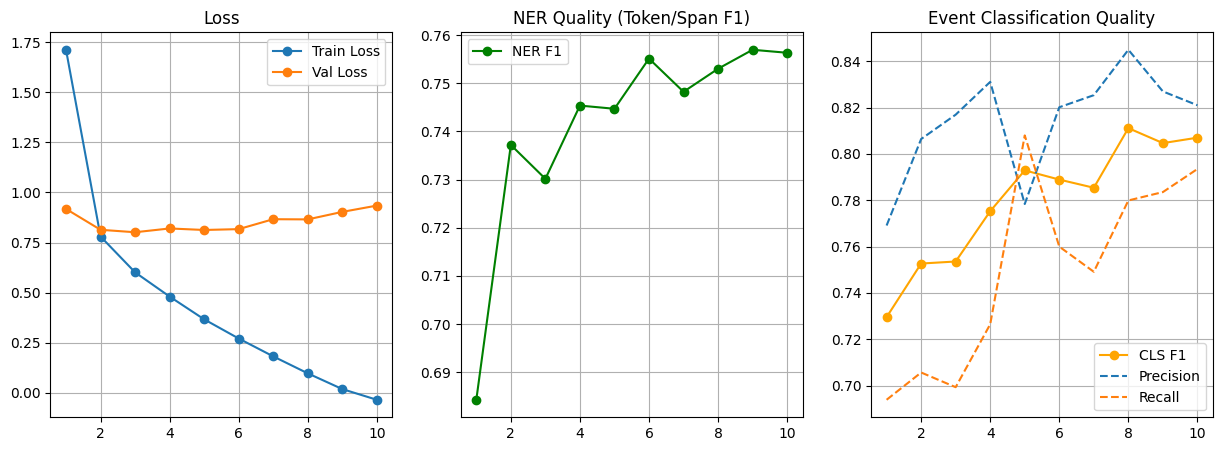


=== Final Evaluation on TEST Set ===
Test Token-level (Span) F1: 0.7741
Test CLS Micro-F1:          0.8076
Test CLS Precision:         0.8214
Test CLS Recall:            0.7943


In [ ]:

def evaluate_model(model, dataloader, device, id2tag, event_list, threshold=0.5):
    model.eval()
    
    # Контейнеры для результатов
    all_ner_preds = []
    all_ner_labels = []
    all_cls_preds = []
    all_cls_labels = []
    
    total_loss = 0
    
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            cls_labels = batch['cls_labels'].to(device)
            
            out = model(input_ids, mask, labels, cls_labels)
            if out['loss'] is not None:
                total_loss += out['loss'].item()
            
            logits = out['ner_logits']
            predictions = torch.argmax(logits, dim=2)
            
            # Преобразуем ID в теги, исключая спецтокены (-100)
            for pred_seq, label_seq in zip(predictions, labels):
                true_seq_tags = []
                pred_seq_tags = []
                for p, l in zip(pred_seq, label_seq):
                    if l.item() != -100:
                        true_seq_tags.append(id2tag[l.item()])
                        pred_seq_tags.append(id2tag[p.item()])
                all_ner_preds.append(pred_seq_tags)
                all_ner_labels.append(true_seq_tags)
            
            cls_probs = torch.sigmoid(out['cls_logits'])
            cls_preds_bin = (cls_probs > threshold).float()
            
            all_cls_preds.extend(cls_preds_bin.cpu().numpy())
            all_cls_labels.extend(cls_labels.cpu().numpy())
            
    avg_loss = total_loss / len(dataloader)
    
    
    ner_f1 = seq_f1_score(all_ner_labels, all_ner_preds)
    
    cls_micro_f1 = f1_score(all_cls_labels, all_cls_preds, average='micro', zero_division=0)
    cls_precision = precision_score(all_cls_labels, all_cls_preds, average='micro', zero_division=0)
    cls_recall = recall_score(all_cls_labels, all_cls_preds, average='micro', zero_division=0)
    
    return {
        'loss': avg_loss,
        'ner_f1': ner_f1,
        'cls_f1': cls_micro_f1,
        'cls_precision': cls_precision,
        'cls_recall': cls_recall
    }

# --- Цикл Обучения ---
logs = []

print(f"Запуск обучения на {EPOCHS} эпох...")
print(f"Device: {device}")
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    for batch in loop:
        input_ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        cls_labels = batch['cls_labels'].to(device)
        
        optimizer.zero_grad()
        
        out = model(input_ids, mask, labels, cls_labels)
        loss = out['loss']
        
        loss.backward()
        
        # Gradient Clipping
        utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)
        
        optimizer.step()
        scheduler.step()
        
        train_loss += loss.item()
        
        loop.set_postfix({
            'loss': f"{loss.item():.3f}",
            's_ner': f"{out['metrics']['sigma_ner']:.2f}",
            's_cls': f"{out['metrics']['sigma_cls']:.2f}"
        })
        
    avg_train_loss = train_loss / len(train_loader)
    
    val_metrics = evaluate_model(model, dev_loader, device, id2tag, event_list)
    
    epoch_log = {
        'epoch': epoch + 1,
        'train_loss': avg_train_loss,
        'val_loss': val_metrics['loss'],
        'val_ner_f1': val_metrics['ner_f1'],
        'val_cls_f1': val_metrics['cls_f1'],
        'val_cls_prec': val_metrics['cls_precision'],
        'val_cls_rec': val_metrics['cls_recall']
    }
    logs.append(epoch_log)
    
    print(f"\nEND Epoch {epoch+1}: "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val NER F1: {val_metrics['ner_f1']:.4f} | "
          f"Val CLS F1: {val_metrics['cls_f1']:.4f}")

df_logs = pd.DataFrame(logs)
print("\n=== Training Logs ===")
display(df_logs) 

# Графики
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(df_logs['epoch'], df_logs['train_loss'], label='Train Loss', marker='o')
plt.plot(df_logs['epoch'], df_logs['val_loss'], label='Val Loss', marker='o')
plt.title('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(df_logs['epoch'], df_logs['val_ner_f1'], label='NER F1', color='green', marker='o')
plt.title('NER Quality (Token/Span F1)')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(df_logs['epoch'], df_logs['val_cls_f1'], label='CLS F1', color='orange', marker='o')
plt.plot(df_logs['epoch'], df_logs['val_cls_prec'], label='Precision', linestyle='--')
plt.plot(df_logs['epoch'], df_logs['val_cls_rec'], label='Recall', linestyle='--')
plt.title('Event Classification Quality')
plt.legend()
plt.grid(True)

plt.show()

print("\n=== Final Evaluation on TEST Set ===")
test_metrics = evaluate_model(model, test_loader, device, id2tag, event_list)

print(f"Test Token-level (Span) F1: {test_metrics['ner_f1']:.4f}")
print(f"Test CLS Micro-F1:          {test_metrics['cls_f1']:.4f}")
print(f"Test CLS Precision:         {test_metrics['cls_precision']:.4f}")
print(f"Test CLS Recall:            {test_metrics['cls_recall']:.4f}")

##### Выводы по проведенному обучению

Была обучена совместная модель на базе RuBERT для решения 2 задач: извлечения сущностей и классификации событий. Обучение проводилось в течение 10 эпох с использованием uncertainty weighting для балансировки классов. 
1. Модель демонстрирует стабильный рост метрик на валидации. Резких скачков/падений не наблюдается. 
2. Значение train_loss ушло в отрицательную зону. Это нормальное поведение для используемой лосс-функции. Когда модель становится уверенной в предсказаниях, параметры дисперсии уменьшаются, а их логарифм становится отрицательным, что и уменьшает сумму.
3. Основной прирост качества произошел в первые 3-4 эпохи, после чего метрики вышли на плато с медленным улучшением. 10 эпох оказалось достаточно для качественного обучения модели.
4. F1, демонстрирующий качество NER на тестовой выборке составил 0.7741.Это высокий показатель для датасета, с которым выполнялась задача.
5. precision =  0.8214 на тесте показывает, что модель работает осторожно. Ставит тег события, но с высокой вероятностью он верен. Это позволяет не создавать ложные инциденты. recall =   0.7943 чуть ниже точности. Модель пропускает около 20% событий, вероятно, неявно выраженных или редко встречающихся в обучающей выборке.
6. Параметры неопределенности s_ner, s_cls уменьшались синхронно, что говорит о том, что обе задачи имеют схожую сложность для модели. Ни одна из них не доминировала и не подавляла градиенты.

Для дальнейшего улучшения модели можно:
1. Увеличить вес recall в задаче CLS;
2. Проанализировать ошибки на редких классах событий;


##### 6. Инференс, квантизация и анализ ошибок

In [ ]:
# инференс
def predict_text(text, model, tokenizer, device, id2tag, event_list, threshold=0.5):
    model.eval()
    
    # 1. Токенизация
    encoding = tokenizer(
        text, 
        return_tensors='pt', 
        truncation=True, 
        max_length=512
    )
    
    input_ids = encoding['input_ids'].to(device)
    mask = encoding['attention_mask'].to(device)
    
    # 2. Предсказание
    with torch.no_grad():
        out = model(input_ids, mask)
        
    # 3. Декодинг NER
    ner_logits = out['ner_logits'][0] # [Seq, Num_Tags]
    pred_ids = torch.argmax(ner_logits, dim=1).cpu().numpy()
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
    
    ner_results = []
    # Проходим по токенам, исключая спецтокены
    for idx, token in enumerate(tokens):
        if token in ['[CLS]', '[SEP]', '[PAD]']:
            continue
        
        tag_id = pred_ids[idx]
        tag = id2tag[tag_id]
        
        ner_results.append((token, tag))

    # 4. Декодинг CLS
    cls_logits = out['cls_logits'][0]
    cls_probs = torch.sigmoid(cls_logits).cpu().numpy()
    
    detected_events = []
    for i, prob in enumerate(cls_probs):
        if prob > threshold:
            detected_events.append((event_list[i], float(prob)))
            
    # Сортируем события по уверенности
    detected_events.sort(key=lambda x: x[1], reverse=True)
    
    return ner_results, detected_events

def print_prediction(text, ner_res, cls_res):
    print(f"\nТекст: {text}")
    print("-" * 50)
    
    print("NER (Сущности):")
    current_entity = []
    current_type = None
    
    found_entities = False
    for token, tag in ner_res:
        if tag.startswith("B-"):
            if current_entity:
                print(f"   • {''.join(current_entity).replace('##', '')} -> {current_type}")
            current_type = tag[2:]
            current_entity = [token]
            found_entities = True
        elif tag.startswith("I-") and current_type == tag[2:]:
            current_entity.append(token)
        else:
            if current_entity:
                print(f"   • {''.join(current_entity).replace('##', '')} -> {current_type}")
                current_entity = []
                current_type = None
    if current_entity:
        print(f"   • {''.join(current_entity).replace('##', '')} -> {current_type}")
        
    if not found_entities:
        print("   (Сущности не найдены)")

    print("\n CLS (События/Отношения):")
    if cls_res:
        for evt, prob in cls_res:
            print(f"   • {evt:<25} ({prob:.1%})")
    else:
        print("   (События не обнаружены)")
    print("=" * 60)

In [27]:
# Примеры текстов
manual_examples = [
    "Певица Мари Краймбери готовится к выступлению на Ледовой Арене в Новосибирске",
    "Доктор Фуфелшмерц отдыхает в Париже вместе с Перри утконосом",
    "Офисы Яндекса есть в Москве, Санкт-Петербурге и даже в Перми",
    "На чемпионате мира в Катаре сборная Аргентины обыграла Францию в финале.",
    "Илон Маск, основатель компании SpaceX, в очередной раз дал интервью на русском языке",
    "Лариса Долина принудительно покинула свою квартиру в Хамовниках и передала ключи адвокату Лурье",
    "Зендея скоро появится на экранах в новом сезоне сериала в апреле",
    "Лабубу и дубайский шоколад были самыми продаваемыми товарами в первой половине 2025 года в России",
    "Собор Парижской Богоматери - одна из самых популярных достопримечательностей",
    "Я не знаю, кто является президентом Ямайки"
]

print("---ЗАПУСК ИНФЕРЕНСА НА РУЧНЫХ ПРИМЕРАХ---\n")

for text in manual_examples:
    ner, cls = predict_text(text, model, tokenizer, device, id2tag, event_list, threshold=0.5)
    print_prediction(text, ner, cls)

---ЗАПУСК ИНФЕРЕНСА НА РУЧНЫХ ПРИМЕРАХ---


Текст: Певица Мари Краймбери готовится к выступлению на Ледовой Арене в Новосибирске
--------------------------------------------------
NER (Сущности):
   • Певица -> PROFESSION
   • МариКраймбери -> PERSON
   • выступлению -> EVENT
   • ЛедовойАрене -> FACILITY
   • Новосибирске -> CITY

 CLS (События/Отношения):
   • TAKES_PLACE_IN            (98.4%)
   • ALTERNATIVE_NAME          (96.5%)
   • LOCATED_IN                (88.8%)
   • PARTICIPANT_IN            (70.6%)
   • POINT_IN_TIME             (67.4%)
   • WORKS_AS                  (61.0%)
   • AGE_IS                    (60.2%)

Текст: Доктор Фуфелшмерц отдыхает в Париже вместе с Перри утконосом
--------------------------------------------------
NER (Сущности):
   • Доктор -> PROFESSION
   • Фуфелшмерц -> PERSON
   • Париже -> CITY
   • Перриутконосом -> PERSON

 CLS (События/Отношения):
   • ALTERNATIVE_NAME          (99.0%)
   • WORKS_AS                  (98.8%)
   • AGE_IS             

##### Выводы по инференсу:
1. Модель демонстрирует высокую точность в выделении стандартных именованных сущностей. NER работает отлично и помогает понимать контекст. CLS подходит для фильтрации новостей, но может давать ложные срабатывания на абстрактныъ предложениях.
2. В визуализации заметно склеивание токенов. Это артефакт функции печати, но внутренние метки модели расставлены верно.
3. С классификацией событий ситуация чуть сложнее: модель склонна реагировать на ключевые слова, а не на реальные факты, т.к. мы решаем задачу на основе всего текста сразу.
4. Проблемные кейсы: в последнем примере модель допустила ошибку переобучения - выдала WORKS_AS и (99.4%)WORKPLACE (98.1%). Модель увидела токены "президент" и "Ямайка". Предполагаю, что в обучающей выборке такая пара почти всегда означала наличия отношения "президент работает в...". Также модель проигнорировала отрицательный контекст ("не знаю"). Еще наблюдается шумный класс ALTERNATIVE_NAME, который появляется почти везде с высокой вероятностью. 

Что можно улушить:
1. Повысить порог для шумных классов.
2. Перейти от классификации документа к классификации пар сущностей, чтобы избежать результата, как в последнем примере.

In [ ]:
print("Подготовка моделей для бенчмарка...")
model_cpu = model.cpu() 
model_cpu.eval()

# Квантизация (Dynamic Quantization)
model_quantized = torch.quantization.quantize_dynamic(
    model_cpu, 
    {torch.nn.Linear}, 
    dtype=torch.qint8
)

def benchmark_model(mdl, dataloader, name="Model"):
    print(f"\nTesting {name}...")
    
    # Замер времени
    start_time = time.time()
    metrics = evaluate_model(mdl, dataloader, torch.device('cpu'), id2tag, event_list)
    end_time = time.time()
    
    total_time = end_time - start_time
    avg_time_per_batch = total_time / len(dataloader)
    
    print(f"Total Time: {total_time:.2f}s")
    print(f"Avg Batch Time: {avg_time_per_batch:.4f}s")
    print(f"NER F1: {metrics['ner_f1']:.4f}")
    print(f"CLS F1: {metrics['cls_f1']:.4f}")
    
    return total_time, metrics

def get_model_size(mdl):
    torch.save(mdl.state_dict(), "temp.p")
    size_mb = os.path.getsize("temp.p") / 1e6
    os.remove("temp.p")
    return size_mb


# Ограничим тест для скорости (берем 50 батчей из теста)
mini_test_loader = []
for i, batch in enumerate(test_loader):
    if i >= 50: break
    mini_test_loader.append(batch)

print(f"Размер выборки для теста: {len(mini_test_loader)} батчей.")

# 1. Base Model (FP32)
size_base = get_model_size(model_cpu)
time_base, metrics_base = benchmark_model(model_cpu, mini_test_loader, "Base Model (FP32)")

# 2. Quantized Model (INT8)
size_quant = get_model_size(model_quantized)
time_quant, metrics_quant = benchmark_model(model_quantized, mini_test_loader, "Quantized Model (INT8)")

print("\n" + "="*40)
print("       РЕЗУЛЬТАТЫ СРАВНЕНИЯ")
print("="*40)
print(f"{'Metric':<20} | {'Base (FP32)':<15} | {'Quantized (INT8)':<15} | {'Diff':<10}")
print("-" * 65)
print(f"{'Size (MB)':<20} | {size_base:<15.2f} | {size_quant:<15.2f} | x{size_base/size_quant:.2f} smaller")
print(f"{'Inference Time (s)':<20} | {time_base:<15.2f} | {time_quant:<15.2f} | x{time_base/time_quant:.2f} faster")
print(f"{'NER F1':<20} | {metrics_base['ner_f1']:<15.4f} | {metrics_quant['ner_f1']:<15.4f} | {metrics_quant['ner_f1']-metrics_base['ner_f1']:.4f}")
print(f"{'CLS F1':<20} | {metrics_base['cls_f1']:<15.4f} | {metrics_quant['cls_f1']:<15.4f} | {metrics_quant['cls_f1']-metrics_base['cls_f1']:.4f}")

Подготовка моделей для бенчмарка...


/tmp/ipykernel_69023/2506784356.py:6: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  model_quantized = torch.quantization.quantize_dynamic(


Размер выборки для теста: 12 батчей.

Testing Base Model (FP32)...
Total Time: 24.70s
Avg Batch Time: 2.0581s
NER F1: 0.7741
CLS F1: 0.8076

Testing Quantized Model (INT8)...
Total Time: 18.26s
Avg Batch Time: 1.5213s
NER F1: 0.7482
CLS F1: 0.8059

       РЕЗУЛЬТАТЫ СРАВНЕНИЯ
Metric               | Base (FP32)     | Quantized (INT8) | Diff      
-----------------------------------------------------------------
Size (MB)            | 711.75          | 455.03          | x1.56 smaller
Inference Time (s)   | 24.70           | 18.26           | x1.35 faster
NER F1               | 0.7741          | 0.7482          | -0.0258
CLS F1               | 0.8076          | 0.8059          | -0.0017


##### Выводы по квантизации

1. Квантизованная модель ускорилась в 1.35 раза, что является ощутимым улучшением.
2. Размер уменьшился в 1.56 раз, что позволяет сэкономить гораздо больше места в памяти.
3. Потери качества на NER (-0.0258) и CLS (-0.0017) незначительны, минимальны. А это означает, что модель оказалась вполне устойчивой к квантизации. 